<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X shape: (826, 17)
y shape: (826,)

--- Tuning max_depth using Walk-Forward Validation ---
Evaluating max_depth = 3...
  max_depth=3 → RMSE: 43.013
Evaluating max_depth = 5...
  max_depth=5 → RMSE: 22.906
Evaluating max_depth = 7...
  max_depth=7 → RMSE: 21.186
Evaluating max_depth = 10...
  max_depth=10 → RMSE: 22.950

--- max_depth Comparison ---
max_depth=3  → RMSE: 43.013
max_depth=5  → RMSE: 22.906
max_depth=7  → RMSE: 21.186
max_depth=10  → RMSE: 22.950
Best depth   → 7 with RMSE 21.186

--- Performing final Walk-Forward Validation with best_max_depth = 7 ---
Starting walk-forward validation for 166 steps...
Predicted 50/166 steps.
Predicted 100/166 steps.
Predicted 150/166 steps.
Predicted 166/166 steps.
Walk-forward RMSE     : 21.186
Walk-forward R² Score : 0.939


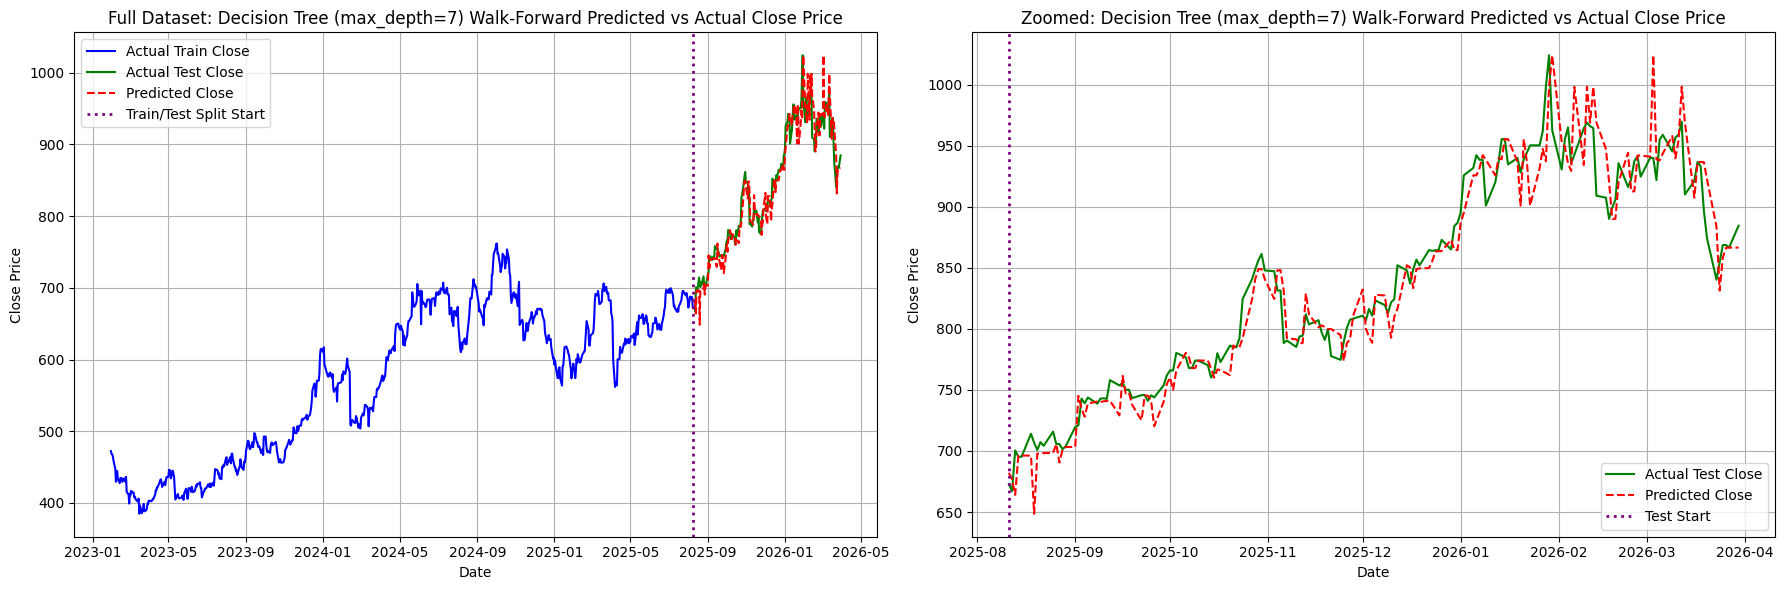

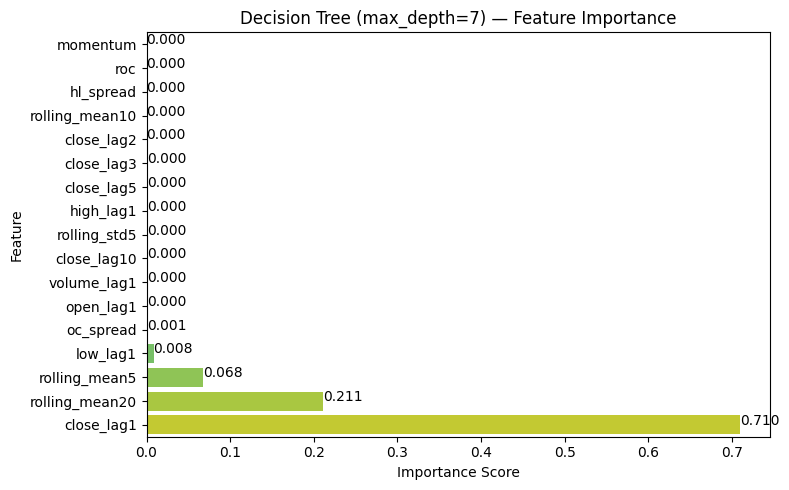


--- Final Summary ---
Model                 : Decision Tree (Walk-Forward, max_depth=7)
Input Features        : open_lag1, high_lag1, low_lag1, volume_lag1, hl_spread, oc_spread, close_lag1, close_lag2, close_lag3, close_lag5, close_lag10, momentum, roc, rolling_mean5, rolling_std5, rolling_mean10, rolling_mean20
Target                : close
Initial Train size    : 660 (for walk-forward)
Test size             : 166 (for walk-forward)
Walk-forward RMSE     : 21.186
Walk-forward R² Score : 0.939
Most Important Feature: close_lag1 (0.710)


In [5]:
import warnings
warnings.filterwarnings('ignore')

!pip install odfpy

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load data
df = pd.read_excel('/content/Hindustan_copper.ods', engine='odf')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()
df = df.asfreq('B', method='ffill')

# Filter to use only the last 2 years of data (2023-2026)
df = df['2023-01-01':]

# Step 2: Create features using ONLY yesterday's values (no data leakage)
df['close_lag1']    = df['close'].shift(1)
df['close_lag2']    = df['close'].shift(2)
df['close_lag3']    = df['close'].shift(3)
df['close_lag5']    = df['close'].shift(5)
df['close_lag10']   = df['close'].shift(10)
df['open_lag1']     = df['open'].shift(1)
df['high_lag1']     = df['high'].shift(1)
df['low_lag1']      = df['low'].shift(1)
df['volume_lag1']   = df['volume'].shift(1)
df['hl_spread']     = df['high'].shift(1) - df['low'].shift(1)
df['oc_spread']     = df['open'].shift(1) - df['close'].shift(1)
df['momentum']      = df['close'].shift(1) - df['close'].shift(5)
df['roc']           = (df['close'].shift(1) - df['close'].shift(5)) / df['close'].shift(5)
df['rolling_mean5'] = df['close'].shift(1).rolling(5).mean()
df['rolling_std5']  = df['close'].shift(1).rolling(5).std()
df['rolling_mean10']= df['close'].shift(1).rolling(10).mean()
df['rolling_mean20']= df['close'].shift(1).rolling(20).mean()

df.dropna(inplace=True)

# Step 3: Define X and y (all lag features)
X = df[['open_lag1', 'high_lag1', 'low_lag1', 'volume_lag1',
        'hl_spread', 'oc_spread',
        'close_lag1', 'close_lag2', 'close_lag3', 'close_lag5', 'close_lag10',
        'momentum', 'roc',
        'rolling_mean5', 'rolling_std5', 'rolling_mean10', 'rolling_mean20']]
y = df['close']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Initial split for defining the walk-forward window (80% train, 20% test of the 2-year data)
train_split_idx = int(len(X) * 0.8)

# --- Hyperparameter Tuning for max_depth ---
max_depth_values = [3, 5, 7, 10]
rmse_results = {}
best_rmse = float('inf')
best_max_depth = None

print("\n--- Tuning max_depth using Walk-Forward Validation ---")
for md in max_depth_values:
    print(f"Evaluating max_depth = {md}...")
    current_predictions = []
    current_actuals = []
    current_indices = []
    scaler = StandardScaler()
    model_tune = DecisionTreeRegressor(max_depth=md, random_state=42)

    for i in range(len(y.iloc[train_split_idx:])):
        X_train_curr = X.iloc[:train_split_idx + i]
        y_train_curr = y.iloc[:train_split_idx + i]
        X_test_curr = X.iloc[[train_split_idx + i]]
        y_test_curr = y.iloc[[train_split_idx + i]]

        X_train_scaled = scaler.fit_transform(X_train_curr)
        X_test_scaled  = scaler.transform(X_test_curr)

        model_tune.fit(X_train_scaled, y_train_curr)
        y_pred_curr = model_tune.predict(X_test_scaled)

        current_predictions.append(y_pred_curr[0])
        current_actuals.append(y_test_curr.iloc[0])
        current_indices.append(y_test_curr.index[0])

    y_pred_wf_tune = pd.Series(current_predictions, index=current_indices)
    y_actual_wf_tune = pd.Series(current_actuals, index=current_indices)

    rmse_md = np.sqrt(mean_squared_error(y_actual_wf_tune, y_pred_wf_tune))
    rmse_results[md] = rmse_md

    if rmse_md < best_rmse:
        best_rmse = rmse_md
        best_max_depth = md

    print(f"  max_depth={md} → RMSE: {rmse_md:.3f}")

print("\n--- max_depth Comparison ---")
for md, rmse_val in rmse_results.items():
    print(f"max_depth={md}  → RMSE: {rmse_val:.3f}")
print(f"Best depth   → {best_max_depth} with RMSE {best_rmse:.3f}")


# --- Final Walk-forward validation with Best max_depth ---
print(f"\n--- Performing final Walk-Forward Validation with best_max_depth = {best_max_depth} ---")
X_walk_forward_test = X.iloc[train_split_idx:]
y_walk_forward_test = y.iloc[train_split_idx:]

predictions = []
actuals = []
indices = []

model = DecisionTreeRegressor(max_depth=best_max_depth, random_state=42)
scaler = StandardScaler()

print(f"Starting walk-forward validation for {len(y_walk_forward_test)} steps...")

for i in range(len(y_walk_forward_test)):
    X_train_curr = X.iloc[:train_split_idx + i]
    y_train_curr = y.iloc[:train_split_idx + i]

    X_test_curr = X.iloc[[train_split_idx + i]]
    y_test_curr = y.iloc[[train_split_idx + i]]

    X_train_scaled = scaler.fit_transform(X_train_curr)
    X_test_scaled  = scaler.transform(X_test_curr)

    model.fit(X_train_scaled, y_train_curr)
    y_pred_curr = model.predict(X_test_scaled)

    predictions.append(y_pred_curr[0])
    actuals.append(y_test_curr.iloc[0])
    indices.append(y_test_curr.index[0])

    if (i + 1) % 50 == 0 or (i + 1) == len(y_walk_forward_test):
        print(f"Predicted {i + 1}/{len(y_walk_forward_test)} steps.")

# Convert results to Series for easier handling
y_pred_wf = pd.Series(predictions, index=indices)
y_actual_wf = pd.Series(actuals, index=indices)

# Evaluate overall performance on the walk-forward test set
rmse_wf = np.sqrt(mean_squared_error(y_actual_wf, y_pred_wf))
r2_wf   = r2_score(y_actual_wf, y_pred_wf)
print(f"Walk-forward RMSE     : {rmse_wf:.3f}")
print(f"Walk-forward R² Score : {r2_wf:.3f}")

# Step 8: Plot full view and zoomed view
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(y.iloc[:train_split_idx].index, y.iloc[:train_split_idx], color='blue',  label='Actual Train Close')
plt.plot(y_actual_wf.index, y_actual_wf,  color='green', label='Actual Test Close')
plt.plot(y_pred_wf.index,  y_pred_wf,  color='red', linestyle='--', label='Predicted Close')
plt.axvline(x=y.index[train_split_idx - 1], color='purple', linestyle=':', linewidth=2, label='Train/Test Split Start')
plt.title(f'Full Dataset: Decision Tree (max_depth={best_max_depth}) Walk-Forward Predicted vs Actual Close Price') # Updated title
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(y_actual_wf.index, y_actual_wf,  color='green', label='Actual Test Close')
plt.plot(y_pred_wf.index, y_pred_wf,  color='red', linestyle='--', label='Predicted Close')
plt.axvline(x=y_actual_wf.index[0], color='purple', linestyle=':', linewidth=2, label='Test Start')
plt.title(f'Zoomed: Decision Tree (max_depth={best_max_depth}) Walk-Forward Predicted vs Actual Close Price') # Updated title
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 9: Feature importance chart (using feature_importances_ for Decision Tree)
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
for i, v in enumerate(feat_imp.values):
    plt.text(v, i, f'{v:.3f}')
plt.title(f'Decision Tree (max_depth={best_max_depth}) — Feature Importance') # Updated title
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Step 10: Final summary
best_feature = X.columns[np.argmax(model.feature_importances_)]
best_value   = np.max(model.feature_importances_)
print(f"\n--- Final Summary ---")
print(f"Model                 : Decision Tree (Walk-Forward, max_depth={best_max_depth})") # Updated model name
print(f"Input Features        : {', '.join(X.columns)}")
print(f"Target                : close")
print(f"Initial Train size    : {train_split_idx} (for walk-forward)")
print(f"Test size             : {len(y_walk_forward_test)} (for walk-forward)")
print(f"Walk-forward RMSE     : {rmse_wf:.3f}")
print(f"Walk-forward R² Score : {r2_wf:.3f}")
print(f"Most Important Feature: {best_feature} ({best_value:.3f})")